# NB04: Multi-Panel Figure

Generates Figure 1 for the report.

Run equivalent script: `python src/05_figure.py`

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch
import os

FIG_DIR = os.path.join('..', 'figures')
DATA_DIR = os.path.join('..', 'data')

In [2]:
# Load all data
detail = pd.read_csv(os.path.join(DATA_DIR, 'pairwise_detail.csv'))
df = pd.read_csv(os.path.join(DATA_DIR, 'species_gene_families.csv'))
phy = pd.read_csv(os.path.join(DATA_DIR, 'phylum_cooccurrence.csv'))
phz_tax = pd.read_csv(os.path.join(DATA_DIR, 'phenazine_operon_taxonomy.csv'))
print('Data loaded')

Data loaded


In [3]:
"""
Generate multi-panel figure for macro-micro nutrient co-cycling analysis.

Panel A: Co-occurrence heatmap (nutrient gene x metal gene, phi coefficients)
Panel B: Core vs. accessory fraction per gene family
Panel C: Phylogenetic distribution (phylum-level P-Metal co-occurrence)
Panel D: Phenazine operon carriers — family-level bar chart

Outputs:
  figures/figure1_cooccurrence.png
  figures/figure1_cooccurrence.pdf
"""

import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

FIG_DIR = os.path.join('..', 'figures')
DATA_DIR = os.path.join('..', 'data')
os.makedirs(FIG_DIR, exist_ok=True)

detail = pd.read_csv(os.path.join(DATA_DIR, 'pairwise_detail.csv'))
df = pd.read_csv(os.path.join(DATA_DIR, 'species_gene_families.csv'))
cooc = pd.read_csv(os.path.join(DATA_DIR, 'cooccurrence_matrix.csv'))
phz_tax = pd.read_csv(os.path.join(DATA_DIR, 'phenazine_operon_taxonomy.csv'))
phy = pd.read_csv(os.path.join(DATA_DIR, 'phylum_cooccurrence.csv'))

fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.35)

# --- Panel A: Heatmap ---
ax_a = fig.add_subplot(gs[0, 0])

nutrient_order = ['phoA', 'phoD_pfam', 'pstA', 'pstB', 'pstC', 'pstS',
                  'phnC', 'phnD', 'phnE',
                  'nifH', 'nifD', 'nifH_pfam',
                  'phzF', 'phzA', 'phzB', 'phzD', 'phzG', 'phzS', 'phzM']
metal_order = ['copA', 'corA', 'feoB_pfam', 'HMA_pfam']

nutrient_labels = ['phoA', 'phoD', 'pstA', 'pstB', 'pstC', 'pstS',
                   'phnC', 'phnD', 'phnE',
                   'nifH', 'nifD', 'nifH(Pfam)',
                   'phzF', 'phzA', 'phzB', 'phzD', 'phzG', 'phzS', 'phzM']
metal_labels = ['copA', 'corA', 'feoB', 'HMA']

pivot = detail.pivot(index='nutrient_gene', columns='metal_gene', values='phi')
heatmap_data = np.zeros((len(nutrient_order), len(metal_order)))
for i, ng in enumerate(nutrient_order):
    for j, mg in enumerate(metal_order):
        if ng in pivot.index and mg in pivot.columns:
            heatmap_data[i, j] = pivot.loc[ng, mg]

vmax = max(abs(heatmap_data.min()), abs(heatmap_data.max()))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

im = ax_a.imshow(heatmap_data, cmap='RdBu_r', aspect='auto', norm=norm)
ax_a.set_xticks(range(len(metal_labels)))
ax_a.set_xticklabels(metal_labels, fontsize=9, rotation=45, ha='right')
ax_a.set_yticks(range(len(nutrient_labels)))
ax_a.set_yticklabels(nutrient_labels, fontsize=8)

for i in range(len(nutrient_order)):
    for j in range(len(metal_order)):
        val = heatmap_data[i, j]
        color = 'white' if abs(val) > 0.15 else 'black'
        ax_a.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=6.5, color=color)

ax_a.axhline(y=8.5, color='gray', linewidth=1.5, linestyle='--')
ax_a.axhline(y=11.5, color='gray', linewidth=1.5, linestyle='--')

ax_a.text(-1.8, 4, 'P-acq', fontsize=8, va='center', ha='center', fontstyle='italic', color='#2166ac')
ax_a.text(-1.8, 10, 'N-fix', fontsize=8, va='center', ha='center', fontstyle='italic', color='#4daf4a')
ax_a.text(-1.8, 15, 'Phz', fontsize=8, va='center', ha='center', fontstyle='italic', color='#e41a1c')

cbar = plt.colorbar(im, ax=ax_a, shrink=0.6, pad=0.02)
cbar.set_label('Phi coefficient', fontsize=9)
ax_a.set_title('A. Gene co-occurrence (phi)', fontsize=11, fontweight='bold', loc='left')

# --- Panel B: Core fraction bars ---
ax_b = fig.add_subplot(gs[0, 1])

gene_order = ['phoA', 'phoD_pfam', 'pstA', 'pstC', 'pstS', 'phnC', 'phnE',
              'nifH', 'nifD', 'nifH_pfam',
              'phzF', 'phzG', 'phzS',
              'copA', 'corA', 'feoB_pfam', 'HMA_pfam']
gene_labels_b = ['phoA', 'phoD', 'pstA', 'pstC', 'pstS', 'phnC', 'phnE',
                 'nifH', 'nifD', 'nifH(Pfam)',
                 'phzF', 'phzG', 'phzS',
                 'copA', 'corA', 'feoB', 'HMA']

core_fracs = []
colors_b = []
color_map = {
    'P': '#2166ac',
    'N': '#4daf4a',
    'Phz': '#e41a1c',
    'M': '#984ea3',
}

p_genes_set = {'phoA', 'phoD_pfam', 'pstA', 'pstC', 'pstS', 'phnC', 'phnE'}
n_genes_set = {'nifH', 'nifD', 'nifH_pfam'}
phz_genes_set = {'phzF', 'phzG', 'phzS'}
m_genes_set = {'copA', 'corA', 'feoB_pfam', 'HMA_pfam'}

for g in gene_order:
    total = int(df[f'n_{g}'].sum())
    core = int(df[f'n_{g}_core'].sum())
    frac = core / total if total > 0 else 0
    core_fracs.append(frac)

    if g in p_genes_set:
        colors_b.append(color_map['P'])
    elif g in n_genes_set:
        colors_b.append(color_map['N'])
    elif g in phz_genes_set:
        colors_b.append(color_map['Phz'])
    else:
        colors_b.append(color_map['M'])

bars = ax_b.barh(range(len(gene_order)), core_fracs, color=colors_b, edgecolor='white', linewidth=0.5)
ax_b.set_yticks(range(len(gene_labels_b)))
ax_b.set_yticklabels(gene_labels_b, fontsize=8)
ax_b.set_xlabel('Core genome fraction', fontsize=9)
ax_b.set_xlim(0, 1)
ax_b.invert_yaxis()
ax_b.axvline(x=0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

for i, v in enumerate(core_fracs):
    ax_b.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=7)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_map['P'], label='P-acquisition'),
    Patch(facecolor=color_map['N'], label='N-fixation'),
    Patch(facecolor=color_map['Phz'], label='Phenazine'),
    Patch(facecolor=color_map['M'], label='Metal-handling'),
]
ax_b.legend(handles=legend_elements, loc='lower right', fontsize=7, framealpha=0.9)
ax_b.set_title('B. Core genome fraction', fontsize=11, fontweight='bold', loc='left')

# --- Panel C: Phylum stratification ---
ax_c = fig.add_subplot(gs[1, 0])

top_phyla = phy[phy['n_species'] >= 50].sort_values('n_species', ascending=False).head(12).copy()
top_phyla['phylum_short'] = top_phyla['phylum'].str.replace('p__', '')
top_phyla = top_phyla.sort_values('phi_PM')

y_pos = range(len(top_phyla))
colors_c = []
for _, row in top_phyla.iterrows():
    if row['n_Phz_operon'] > 0:
        colors_c.append('#e41a1c')
    elif row['phi_PM'] > 0.15:
        colors_c.append('#2166ac')
    elif row['phi_PM'] > 0.05:
        colors_c.append('#92c5de')
    else:
        colors_c.append('#d1e5f0')

ax_c.barh(y_pos, top_phyla['phi_PM'].values, color=colors_c, edgecolor='white')
ax_c.set_yticks(y_pos)
ax_c.set_yticklabels(top_phyla['phylum_short'].values, fontsize=8)
ax_c.set_xlabel('Phi (P-acquisition x Metal-handling)', fontsize=9)
ax_c.axvline(x=0, color='black', linewidth=0.5)

for i, (_, row) in enumerate(top_phyla.iterrows()):
    n = int(row['n_species'])
    phz = int(row['n_Phz_operon'])
    label = f'n={n}'
    if phz > 0:
        label += f', phz={phz}'
    ax_c.text(max(row['phi_PM'] + 0.005, 0.005), i, label, va='center', fontsize=7)

ax_c.set_title('C. Phylum-level P-Metal co-occurrence', fontsize=11, fontweight='bold', loc='left')

# --- Panel D: Phenazine operon taxonomy ---
ax_d = fig.add_subplot(gs[1, 1])

family_counts = phz_tax['family'].value_counts()
family_df = family_counts.reset_index()
family_df.columns = ['family', 'count']
family_df['family_short'] = family_df['family'].str.replace('f__', '')
family_df = family_df.sort_values('count', ascending=True)

colors_d = []
for _, row in family_df.iterrows():
    if 'Pseudomonad' in row['family']:
        colors_d.append('#e41a1c')
    elif 'Streptomyc' in row['family']:
        colors_d.append('#ff7f00')
    elif 'Enterobact' in row['family']:
        colors_d.append('#377eb8')
    elif 'Burkholder' in row['family']:
        colors_d.append('#4daf4a')
    else:
        colors_d.append('#984ea3')

ax_d.barh(range(len(family_df)), family_df['count'].values, color=colors_d, edgecolor='white')
ax_d.set_yticks(range(len(family_df)))
ax_d.set_yticklabels(family_df['family_short'].values, fontsize=8)
ax_d.set_xlabel('Number of species with phenazine operon', fontsize=9)

for i, v in enumerate(family_df['count'].values):
    ax_d.text(v + 0.3, i, str(v), va='center', fontsize=8, fontweight='bold')

ax_d.set_title('D. Phenazine operon carriers by family', fontsize=11, fontweight='bold', loc='left')

plt.suptitle('Macro-Micro Nutrient Gene Co-occurrence Across 27,682 Bacterial Pangenomes',
             fontsize=13, fontweight='bold', y=0.98)

fig.savefig(os.path.join(FIG_DIR, 'figure1_cooccurrence.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'figure1_cooccurrence.pdf'), bbox_inches='tight')
print(f"Saved figure1_cooccurrence.png and .pdf")
plt.close()


Saved figure1_cooccurrence.png and .pdf


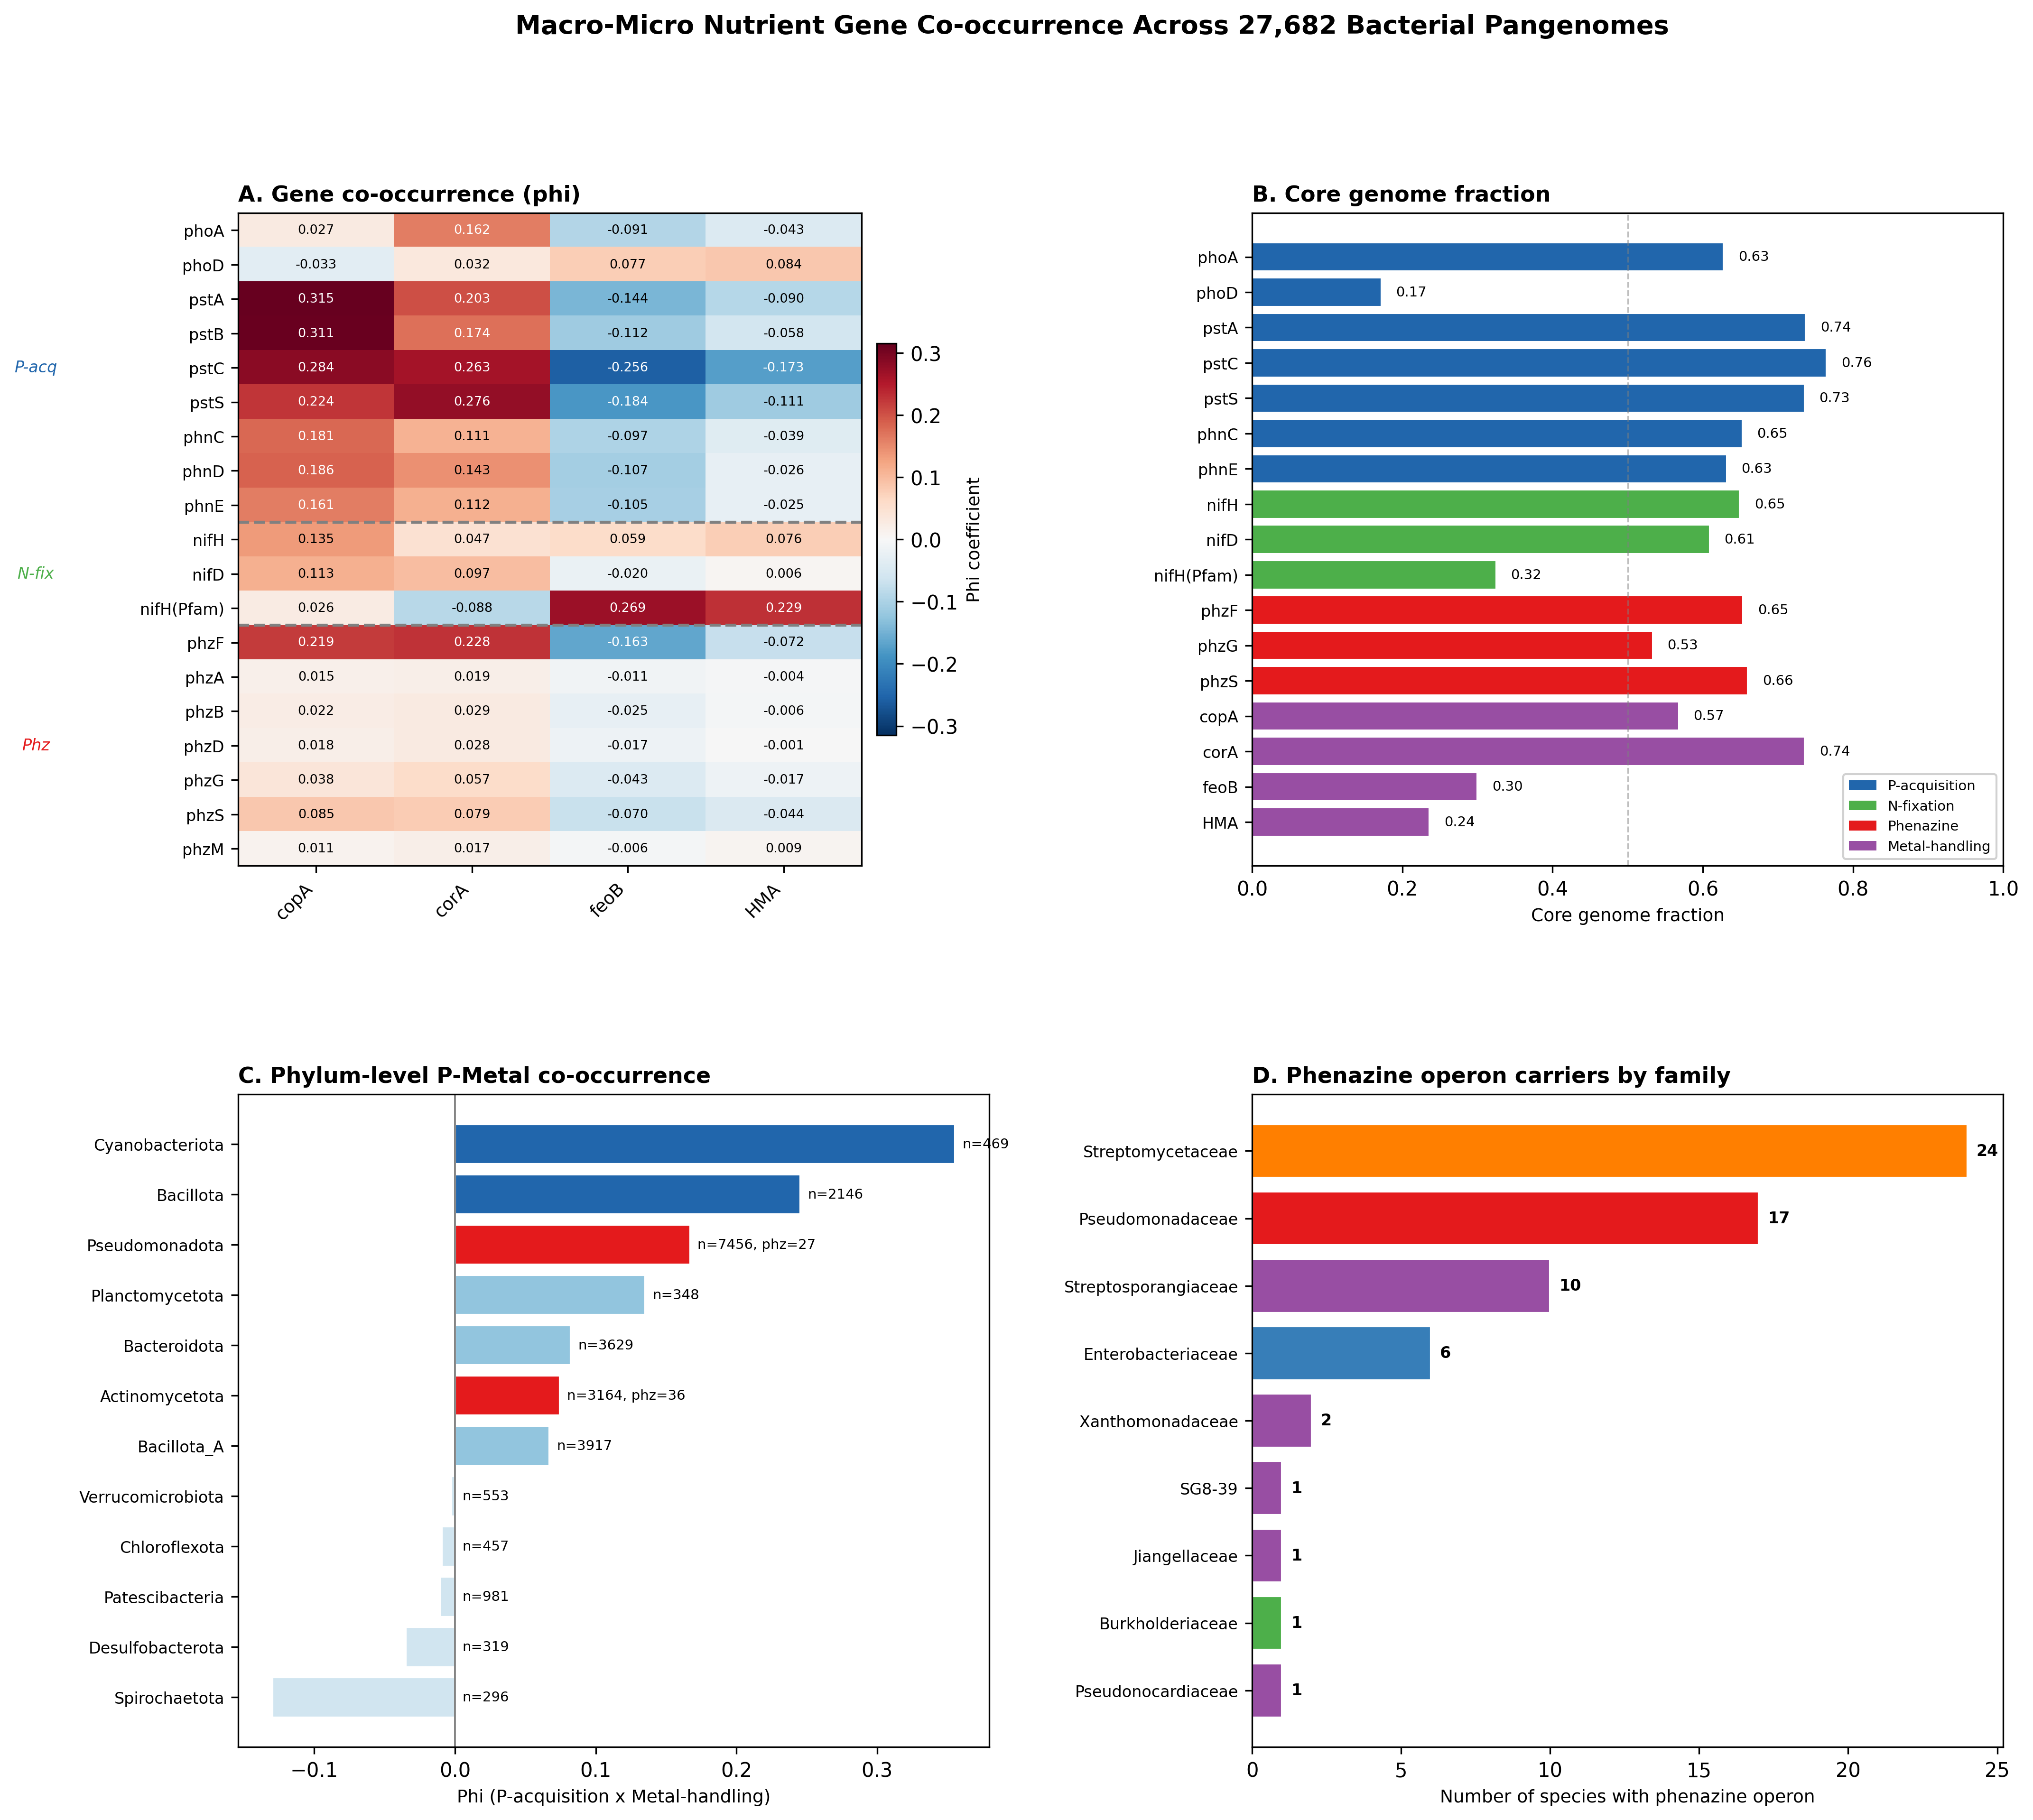

In [4]:
from IPython.display import Image
Image(os.path.join(FIG_DIR, "figure1_cooccurrence.png"), width=900)